In [137]:
import cvxpy as cp
from matplotlib import pyplot as plt
import numpy as np

### Q4

#### (b)

In [175]:
def random_pd_matrix(n, lambda_min, lambda_max, seed = 42):
    np.random.seed(seed)
    M = np.random.randn(n, n)
    Q, _ = np.linalg.qr(M)
    eigvals = np.random.uniform(lambda_min, lambda_max, n)
    return Q@np.diag(eigvals)@Q.T

np.random.seed(42)
mu, L, dim, n = 1, 5, 1000, 20
Qs = [random_pd_matrix(dim, mu, L) for _ in range(n)]
cs = [np.random.randn(dim) for _ in range(n)]
y_init = np.random.randn(dim)

In [79]:
y = cp.Variable(dim)

term = cp.norm(y, 1)
for i in range(n):
    Qi_inv = np.linalg.inv(Qs[i])
    term += (y.T@(np.eye(dim)/mu - Qi_inv)@y/2 - cs[i].T@Qi_inv@y - cs[i].T@Qi_inv@cs[i]/2)/n #? Doing 1/2 before y.T gives DCP error

objective = cp.Minimize(term)
constraints = []
problem = cp.Problem(objective, constraints)

problem.solve() 

np.float64(-199.4034930586936)

In [82]:
sum = 0
for i in range(n):
    sum -=  cs[i].T@Qi_inv@cs[i]/(2*n)
print(sum)

-199.4034930586936


#### (e)

In [180]:
from concurrent.futures import ThreadPoolExecutor
def compute_gradient(i):
    '''
    computes gradient of phii
    '''
    # compute gradient for agent i
    # return gradient_i
    return lambda y: y/mu - Qi_inv@(y+cs[i])
    
num_threads = n
with ThreadPoolExecutor(max_workers = num_threads) as executor:
    gradients = list(executor.map(compute_gradient, range(n)))

def phii(yi, i):
    # print(yi.shape)
    # print(cs[i].shape)
    # print(Qs[i].shape)
    return np.linalg.norm(yi)**2/(2*mu) - 1/2*(yi+cs[i]).T@np.linalg.inv(Qs[i])@(yi+cs[i])

def fi(yi, i):
    return phii(yi, i) + np.linalg.norm(yi, 1)

def f(y):
    fvalue = 0
    for i in range(n):
        fvalue += fi(y, i)
    fvalue /= n
    return fvalue

In [183]:
alpha = 2/L
num_iters = 100
# y_star = y.value
y_star = np.zeros(dim) #? should be y.value ideally
dist_f, dist_y, itr_vec = [], [], []
u = np.zeros((num_iters+1, n, dim))
y = np.zeros((num_iters+1, n, dim))
# print("y_initialization:", y.shape)
for i in range(n):
    y[0, i, :] = y_init
z = np.zeros((num_iters+1, dim))

for k in range(num_iters):
    print("Iter:", k)
    itr_vec.append(k+1)
    # update y
    for i in range(n):
        v = z[k, :] - u[k, i, :]
        temp = v - alpha*gradients[i](v)
        # print("temp shape:", temp.shape)
        for j in range(dim):
            y[k+1, i, j] = np.sign(temp[j])*max(abs(temp[j]) - alpha, 0)
        # y[k+1, i, :] = prox_alphafi(z[k, :] - u[k, i, :])
    # update z
    z[k+1, :] = 0
    for i in range(n):
        z[k+1, :] += y[k+1, i, :] + u[k, i, :]
    z[k+1, :] /= n
    # update u
    for i in range(n):
        u[k+1, i, :] = u[k, i, :] + y[k+1, i, :] - z[k+1, :]
    
    # Computing numbers to plot
    y_k1_avg = 0
    for i in range(n):
        y_k1_avg += y[k+1, i, :]
    y_k1_avg /= n
    dist_f.append(abs(f(y_k1_avg) - f(y_star)))
    dist_y.append(np.linalg.norm(y[k+1] - y_star))

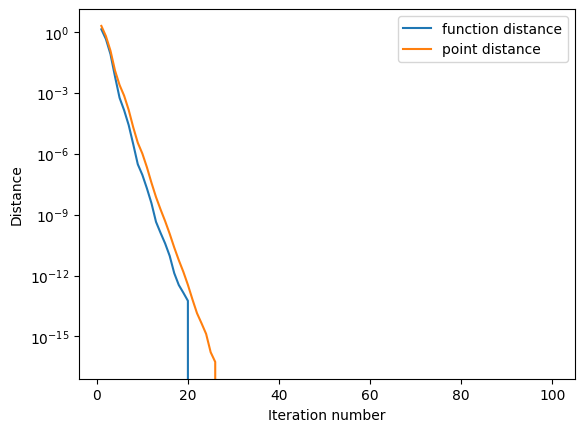

In [184]:
plt.plot(itr_vec, dist_f, label = "function distance")
plt.plot(itr_vec, dist_y, label = "point distance")
plt.yscale("log")
plt.xlabel("Iteration number")
plt.ylabel("Distance")
plt.legend()
plt.show()

##### As seen, parallelizing processes reduces time. Since each update in i is independent of other i's (one worker is independent of the others as far as first step (of individual i updates) is concerned), parallelizing the system would speed up processes and hence, reduce time!

### Q5

In [203]:
np.random.seed(42) # For reproducibility

# System parameters
n, T, rho = 2, 5, 0.1
sigma = 0.40 # For Gaussian uncertainty samples
A = np.array([[1.1, 0.2], [0.0, 0.9]])
b_bar = np.array([1.0, 0.5])
x_init = np.array([10.0, 5.0])
# Safe temperature constraints : Cx <= d
C = np.array([[1.0, 1.0], [0.5, -0.5]])
q = C.shape[0]
d = np.array([25.0, 8.0])

for l in range(q):
    # constraints.append(C@x_init<=d) # writing directly as vectors gives errors
    print(C[l].T@x_init <= d[l])


True
True


#### (d)

In [204]:
def solve_robust_problem(rho):
    # variables
    u = cp.Variable(T) # [u0, u1, ..., uT-1]
    X = cp.Variable(n*(T+1)) # [x0, x1, ..., xT] => n*(T+1)

    # constants
    A_power = [np.eye(n)] # A_power[i] = A^(i)
    for i in range(T):
        A_power.append(A_power[i]@A)

    A_stylized = np.zeros((n*T, n))
    for i in range(T):
        A_stylized[i*n:(i+1)*n, :] = A_power[i+1]

    B_stylized = np.zeros((n*T, T))
    for i in range(T):
        for j in range(i):
            B_stylized[i*n:(i+1)*n, j] = A_power[i-j]@b_bar

    # objective
    objective = cp.Minimize(cp.norm(u)**2)

    # constraints
    constraints = [
        X[n:] == A_stylized@x_init + B_stylized@u, # dynamics
        # uncertainty constraint
        # temperature constraint
        ]

    constraints.append(X[:n] == x_init)
    # for t in range(T):
    #     constraints.append(cp.norm(X[(t+1)*n:(t+2)*n] - A@X[t*n:(t+1)*n] - b_bar) <= rho*cp.abs(u[t]))

    for t in range(1, T+1):
        for l in range(q):
            # constraint = C[l].T@(A@X[t*n:(t+1)*n] + b_bar*u[t]) + np.linalg.norm(C[l], 2)*rho*cp.abs(u[t])<=d[l]
            constraint = C[l].T@(A@X[(t-1)*n:t*n] + b_bar*u[t-1]) + np.linalg.norm(C[l], 2)*rho*cp.abs(u[t-1])<=d[l]
            constraints.append(constraint)

    # define problem
    problem = cp.Problem(objective, constraints)

    # solve
    problem.solve()
    objval = problem.value
    uval = u.value

    return objval, uval

In [205]:
objval, uval = solve_robust_problem(rho)
print("Objective value:", objval)
print("Control value:", uval)

Objective value: 0.99178580404572
Control value: [-6.78015566e-01 -5.58024030e-01 -4.42456934e-01 -4.61799980e-08
 -1.57866212e-01]


#### (e)

In [206]:
def get_b_vec(num_sim):
    cnt = 0
    delta = np.random.normal(0, sigma, (num_sim, n*T))
    b = np.zeros((num_sim, n*T))
    for i in range(num_sim):
        for j in range(0, T):
            delta_val = delta[i, j*n:(j+1)*n]
            if(np.linalg.norm(delta_val) >= rho):
                cnt += 1
            b[i, j*n:(j+1)*n] = b_bar + delta_val
    return b, cnt

In [211]:
# cnt = 0
# num_sim = 500
# delta = np.random.normal(0, sigma, (num_sim, n*T))
# b = np.zeros((num_sim, n*T))
# for i in range(num_sim):
#     for j in range(0, T):
#         delta_val = delta[i, j*n:(j+1)*n]
#         if(np.linalg.norm(delta_val) >= rho):
#             cnt += 1
#         b[i, j*n:(j+1)*n] = b_bar + delta_val

num_sim = 500
b, cnt = get_b_vec(num_sim)

# Expected to be high since each element of delta has variance sigma**2 and so std dev = sigma which is 4 times rho
print("Probability of delta violating the uncertain constraint:", cnt/(num_sim*T))

Probability of delta violating the uncertain constraint: 0.4388


In [219]:
def get_x_vec(A, b, uval, num_sim, T, x_init):
    '''
    Construct x vector according to the original dynamics
    Args:
        
    Returns:
        a vector of length (T+1)*n
    '''
    n = A.shape[1]
    x_vec = np.zeros((num_sim, (T+1)*n))
    for i in range(num_sim):
        x_vec[i, :n] = x_init
        for t in range(1, T+1):
            # x[t] = A*x[t-1] + b[t-1]*u[t-1]
            x_vec[i, t*n:(t+1)*n] = A@x_vec[i, (t-1)*n:t*n] + b[i, (t-1)*n:t*n]*uval[t-1]
    return x_vec

def get_maximum_violation_probability(x_vec, C, d, T): 
    '''Find the probability of violation for a given x vector'''
    num_sim = x_vec.shape[0]
    ans = 0
    q = C.shape[0]
    n = C.shape[1]
    for t in range(T+1):
        # print("Time:", t)
        cnt_violation = 0
        for sim in range(num_sim):
            mxm = 0 # for a given time and a given simulation, this stores the maximum value of c[l].x[t] -d[l]
            for l in range(q):
                mxm = max(mxm, C[l, :].T@x_vec[sim, t*n:(t+1)*n] - d[l])
            if(mxm > 0): # x[t] does not belong to X_stylized
                cnt_violation += 1
        prob = cnt_violation/num_sim
        # print(f"Probability of violation for time {t}:", prob)
        ans = max(ans, prob)
    # print("Overall maximum probability of violation", ans)
    return ans

x_vec = get_x_vec(A, b, uval, num_sim, T, x_init)
prob_max = get_maximum_violation_probability(x_vec, C, d, T)
print(prob_max)


0.426


#### (f)

In [221]:
epsilon = 0.1

rho_star = -1
mxm = -1
for rho in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    # Why does solve_robust_problem not take b as input? b is fixed for all rhos once we generated delta
    # because b is not an input to robust problem
    objval, uval = solve_robust_problem(rho) 
    x_vec = get_x_vec(A, b, uval, num_sim, T, x_init)
    prob_max = get_maximum_violation_probability(x_vec, C, d, T)
    print(rho, prob_max, objval)
    if(prob_max<=epsilon):
        if(prob_max>=mxm):
            mxm = prob_max
            rho_star = rho

print("")
print(rho_star)

0.1 0.426 0.99178580404572
0.15 0.434 1.0007255369214787
0.2 0.438 1.0078224768069515
0.25 0.446 1.012994717676396
0.3 0.452 1.0161814632338166
0.35 0.46 1.0173447883815712
0.4 0.464 1.0173499385985203
0.45 0.464 1.0173499386484066
0.5 0.464 1.0173499387155984

-1


In [222]:
rho_star = 0.1
objval, uval = solve_robust_problem(rho_star) 
print(objval)
print(uval)
Ntest = 10000
btest, _ = get_b_vec(Ntest)
x_vec = get_x_vec(A, b, uval, num_sim, T, x_init)
prob_max = get_maximum_violation_probability(x_vec, C, d, T)
print(prob_max)

0.99178580404572
[-6.78015566e-01 -5.58024030e-01 -4.42456934e-01 -4.61799980e-08
 -1.57866212e-01]
0.426


#### (i)

In [156]:
# cnt = 0
N = 297
delta = np.random.normal(0, sigma, (N, T, n))
b = np.zeros((N, T, n))
for i in range(N):
    for j in range(T):
        delta_val = delta[i, j, :]
        # if(np.linalg.norm(delta_val) >= rho):
        #     cnt += 1
        b[i, j, :] = b_bar + delta_val

In [158]:
# variables
u = cp.Variable(T) # [u0, u1, ..., uT-1]
X = cp.Variable((N, T+1, n)) # [x0, x1, ..., xT] => n*(T+1)

# objective
objective = cp.Minimize(cp.norm(u)**2)

constraints = []
for k in range(N):
    constraints.append(X[k, 0, :] == x_init)
    for t in range(T):
        constraints.append(X[k, t+1, :] == A@X[k, t, :] + b[k, t, :]*u[t])
        constraints.append(C@X[k, t+1, :] <= d)
        
# define problem
problem = cp.Problem(objective, constraints)

# solve
problem.solve()
objval = problem.value
uval = u.value

print("Optimal objective value:", objval)
print("Control sequence:", uval)

/Users/parthsatishlaturia/Library/Python/3.9/lib/python/site-packages/cvxpy/reductions/solvers/solving_chain.py:418: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


Optimal objective value: 4.460293302757033
Control sequence: [-0.98936253 -1.12973568 -1.25986675 -0.41603987 -0.66693252]


#### (j)

##### N* = 100